# **Disaster-Related Tweet Classification**

## **Datasets & Methods**

This notebook reorganizes the project into a clearer dataset-by-dataset flow:

**Three Datasets:**

1. CrisisLexT6
2. CrisisLexT26
3. Kaggle Disaster Tweets

**Comparision & Limitations:**

4. Combined comparison
5. Sources of irreproducibility

**For each dataset, we run the same 6 approaches:**

1. Keyword filtering
2. Fuzzy keyword filtering
3. TF-IDF + Logistic Regression
4. TF-IDF + Linear SVM
5. Active Learning with TF-IDF + Logistic Regression
6. RoBERTa fine-tuning

By default, the notebook keeps RoBERTa in review mode and first tries to load saved full-run results. When `RUN_FULL_ROBERTA = True`, the same notebook cells fine-tune RoBERTa separately for CrisisLexT6, CrisisLexT26, and Kaggle, then save the real outputs in the executed notebook.

## **Method overview**

| Approach | What it does | How it works |
| --- | --- | --- |
| Keyword filtering | Simple rule-based baseline | Marks a tweet as related if it contains disaster words such as `flood`, `fire`, `earthquake`, or `evacuation`. |
| Fuzzy keyword filtering | More flexible rule-based baseline | Allows small spelling differences from disaster keywords using edit distance. |
| TF-IDF + Logistic Regression | Classical supervised text classifier | Converts tweets into TF-IDF word/phrase features, then learns a linear model for related vs. unrelated tweets. |
| TF-IDF + Linear SVM | Classical supervised text classifier | Uses the same TF-IDF features, but learns a maximum-margin linear classifier. |
| Active Learning + TF-IDF + Logistic Regression | Course-friendly active-learning method | Starts with few labeled tweets, trains Logistic Regression, selects uncertain examples, adds them, and repeats. |
| RoBERTa fine-tuning | Transformer-based neural text classifier | Uses a pretrained Twitter/XLM-RoBERTa model and fine-tunes it on each dataset. The default notebook setting keeps this off so review runs stay fast. |


# **Part 0. Setup & Pre-Processing**

## **0. Setup**

The notebook uses the three local dataset archives in `data/raw`. We load the data once, define reusable helpers, and then analyze each dataset separately.


In [2]:
from pathlib import Path
import html
import re
import time
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_DIR = Path.cwd()
RAW_DIR = PROJECT_DIR / "data" / "raw"

CRISISLEX_T6_ZIP = RAW_DIR / "CrisisLexT6-v1.0.zip"
CRISISLEX_T26_ZIP = RAW_DIR / "CrisisLexT26-v1.0.zip"
KAGGLE_ZIP = RAW_DIR / "nlp-getting-started.zip"

PALETTE = {
    "unrelated": "#4C78A8",
    "related": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "purple": "#B279A2",
    "teal": "#1B998B",
}

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


## **0.1 RoBERTa run controls**

These switches decide what happens when the dataset modeling cells run.

- `RUN_FULL_ROBERTA = True`: train RoBERTa again on the full balanced train/test split for each dataset.
- `RUN_FULL_ROBERTA = False` and `USE_SAVED_FULL_ROBERTA_RESULTS = True`: do not train; load saved full RoBERTa results from `outputs/notebook_roberta_runs` if they exist.
- `RUN_ROBERTA_SMOKE_TEST = True`: optional quick pipeline check. Use this only when you want to rerun the tiny 48-train / 24-test transformer check.
- If no full run is requested and no saved result exists, the notebook falls back to the recorded smoke-test row.

This setup lets us train RoBERTa once, save the real results, and later rerun the notebook quickly without replacing those results with the smoke-test placeholder.


In [3]:
RUN_FULL_ROBERTA = False
USE_SAVED_FULL_ROBERTA_RESULTS = True
RUN_ROBERTA_SMOKE_TEST = False

ROBERTA_MODEL_NAME = "cardiffnlp/twitter-xlm-roberta-base"
ROBERTA_MAX_LENGTH = 64
ROBERTA_BATCH_SIZE = 8
ROBERTA_EPOCHS = 1

# False allows the notebook to download the model if it is not already cached.
# Set this to True only if the model is already downloaded and you want offline-only loading.
ROBERTA_LOCAL_FILES_ONLY = False

# The completed full-run outputs are stored here for this submission copy.
ROBERTA_OUTPUT_ROOT = PROJECT_DIR / "outputs" / "notebook_roberta_runs"


## **1. Data loading helpers**

Each dataset is converted to a shared schema:

- `text`: tweet text
- `label`: `0 = unrelated`, `1 = related`
- `dataset`: dataset name
- `event`: event name when available
- optional source columns such as `keyword` and `location` for Kaggle


In [4]:
def basic_clean(text):
    text = html.unescape(str(text))
    return re.sub(r"\s+", " ", text).strip()


def event_name_from_member(member):
    parts = Path(member).parts
    return parts[1] if len(parts) >= 2 else "unknown_event"


def load_crisislex_t6(zip_path):
    frames = []
    with zipfile.ZipFile(zip_path) as z:
        members = [
            member for member in z.namelist()
            if member.endswith(".csv")
            and "ontopic_offtopic" in member
            and not member.startswith("__MACOSX")
        ]
        for member in members:
            with z.open(member) as f:
                part = pd.read_csv(f, encoding="utf-8", encoding_errors="replace")
            part.columns = part.columns.str.strip().str.lower()
            part = part.rename(columns={"tweet": "text"})
            part["text"] = part["text"].map(basic_clean)
            part["label"] = part["label"].str.strip().map({"off-topic": 0, "on-topic": 1})
            part["dataset"] = "CrisisLexT6"
            part["event"] = event_name_from_member(member)
            frames.append(part[["text", "label", "dataset", "event"]])
    return pd.concat(frames, ignore_index=True)


def load_crisislex_t26(zip_path):
    frames = []
    label_map = {
        "Not related": 0,
        "Related and informative": 1,
        "Related - but not informative": 1,
    }
    with zipfile.ZipFile(zip_path) as z:
        members = [
            member for member in z.namelist()
            if member.endswith(".csv")
            and "tweets_labeled" in member
            and not member.startswith("__MACOSX")
        ]
        for member in members:
            with z.open(member) as f:
                part = pd.read_csv(f, encoding="utf-8", encoding_errors="replace")
            part.columns = part.columns.str.strip()
            part = part.rename(columns={"Tweet Text": "text", "Informativeness": "informativeness"})
            part["text"] = part["text"].map(basic_clean)
            part["label"] = part["informativeness"].str.strip().map(label_map)
            part = part.dropna(subset=["label"])
            part["label"] = part["label"].astype(int)
            part["dataset"] = "CrisisLexT26"
            part["event"] = event_name_from_member(member)
            frames.append(part[["text", "label", "dataset", "event"]])
    return pd.concat(frames, ignore_index=True)


def load_kaggle_disaster_tweets(zip_path):
    with zipfile.ZipFile(zip_path) as z:
        with z.open("train.csv") as f:
            data = pd.read_csv(f)
    return pd.DataFrame({
        "text": data["text"].map(basic_clean),
        "label": data["target"].astype(int),
        "dataset": "Kaggle Disaster Tweets",
        "event": "external_generalization",
        "keyword": data.get("keyword", pd.Series(["unknown"] * len(data))).fillna("unknown"),
        "location": data.get("location", pd.Series(["unknown"] * len(data))).fillna("unknown"),
    })


crisis_t6 = load_crisislex_t6(CRISISLEX_T6_ZIP)
crisis_t26 = load_crisislex_t26(CRISISLEX_T26_ZIP)
kaggle = load_kaggle_disaster_tweets(KAGGLE_ZIP)

datasets = {
    "CrisisLexT6": crisis_t6,
    "CrisisLexT26": crisis_t26,
    "Kaggle Disaster Tweets": kaggle,
}

dataset_overview = pd.DataFrame([
    {
        "dataset": name,
        "rows": len(data),
        "unrelated_0": int((data["label"] == 0).sum()),
        "related_1": int((data["label"] == 1).sum()),
        "events": int(data["event"].nunique()),
    }
    for name, data in datasets.items()
])

dataset_overview


,dataset,rows,unrelated_0,related_1,events
0,CrisisLexT6,60082,27620,32462,6
1,CrisisLexT26,27444,2863,24581,26
2,Kaggle Disaster Tweets,7613,4342,3271,1


## **2. Shared preprocessing, plotting, and modeling helpers**


These helpers remove redundancy. The same code is reused for CrisisLexT6, CrisisLexT26, and Kaggle.

**Why the modeling data is balanced**

The original datasets are not always evenly split between unrelated and related tweets. CrisisLexT26, for example, has many more related tweets than unrelated tweets. If we train and test on the original imbalanced data, a model can look strong just by favoring the larger class.

For the modeling sections, each dataset is balanced by downsampling the larger class. This gives each method an equal number of unrelated and related examples. The EDA charts clearly say when they use original data, while modeling charts and results use the balanced train/test split.

### **Data Cleaning & Balancing**

In [5]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HASH_RE = re.compile(r"#\w+")
NON_WORD_RE = re.compile(r"[^a-zA-Z0-9\s]")


def clean_for_model(text):
    text = basic_clean(text).lower()
    text = URL_RE.sub(" url ", text)
    text = MENTION_RE.sub(" mention ", text)
    text = HASH_RE.sub(" hashtag ", text)
    text = NON_WORD_RE.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()


def add_text_features(data):
    data = data.copy()
    data["n_chars"] = data["text"].str.len()
    data["n_words"] = data["text"].str.split().str.len()
    data["n_url"] = data["text"].apply(lambda text: len(URL_RE.findall(str(text))))
    data["n_mention"] = data["text"].apply(lambda text: len(MENTION_RE.findall(str(text))))
    data["n_hash"] = data["text"].apply(lambda text: len(HASH_RE.findall(str(text))))
    data["is_rt"] = data["text"].str.lower().str.startswith("rt ").astype(int)
    return data


def make_balanced_dataset(data, random_state=RANDOM_STATE):
    n = data["label"].value_counts().min()
    parts = []
    for label_value, group in data.groupby("label"):
        parts.append(group.sample(n=n, random_state=random_state))
    balanced = pd.concat(parts, ignore_index=True)
    return balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)


def make_split(data, test_size=0.2, random_state=RANDOM_STATE):
    balanced = make_balanced_dataset(data, random_state=random_state).copy()
    balanced["clean"] = balanced["text"].map(clean_for_model)
    balanced = balanced[balanced["clean"].str.len() > 0].reset_index(drop=True)
    train_data, test_data = train_test_split(
        balanced,
        test_size=test_size,
        stratify=balanced["label"],
        random_state=random_state,
    )
    return {
        "balanced": balanced,
        "train": train_data.reset_index(drop=True),
        "test": test_data.reset_index(drop=True),
    }


featured_datasets = {name: add_text_features(data) for name, data in datasets.items()}
splits = {name: make_split(data) for name, data in datasets.items()}

pd.DataFrame([
    {
        "dataset": name,
        "balanced_rows": len(parts["balanced"]),
        "train_rows": len(parts["train"]),
        "test_rows": len(parts["test"]),
        "test_unrelated": int((parts["test"]["label"] == 0).sum()),
        "test_related": int((parts["test"]["label"] == 1).sum()),
    }
    for name, parts in splits.items()
])


,dataset,balanced_rows,train_rows,test_rows,test_unrelated,test_related
0,CrisisLexT6,55240,44192,11048,5524,5524
1,CrisisLexT26,5726,4580,1146,573,573
2,Kaggle Disaster Tweets,6542,5233,1309,655,654


### **Used Functions**

In [6]:
def plot_class_balance(data, title):
    counts = data["label"].value_counts().sort_index()
    labels = ["Unrelated (0)", "Related (1)"]
    values = [counts.get(0, 0), counts.get(1, 0)]
    fig, ax = plt.subplots(figsize=(5.5, 4))
    ax.bar(labels, values, color=[PALETTE["unrelated"], PALETTE["related"]])
    ax.set_title(title)
    ax.set_ylabel("Tweets")
    for i, value in enumerate(values):
        ax.text(i, value, f"{value:,}", ha="center", va="bottom")
    plt.tight_layout()
    plt.show()


def plot_event_distribution(data, title, top_n=12):
    if data["event"].nunique() <= 1:
        return
    event_counts = pd.crosstab(data["event"], data["label"])
    event_counts["total"] = event_counts.sum(axis=1)
    event_counts = event_counts.sort_values("total", ascending=False).head(top_n)
    plot_data = event_counts.drop(columns="total")
    fig, ax = plt.subplots(figsize=(9, 4.8))
    plot_data.plot(kind="bar", stacked=True, ax=ax, color=[PALETTE["unrelated"], PALETTE["related"]])
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Tweets")
    ax.legend(["Unrelated (0)", "Related (1)"])
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()


def plot_text_feature_summary(data, title):
    features = ["n_words", "n_url", "n_mention", "n_hash", "is_rt"]
    summary = data.groupby("label")[features].mean().T
    summary.columns = ["Unrelated (0)", "Related (1)"]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    summary.plot(kind="bar", ax=ax, color=[PALETTE["unrelated"], PALETTE["related"]])
    ax.set_title(title)
    ax.set_ylabel("Average value")
    ax.set_xlabel("")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
    return summary


def plot_tweet_length_boxplot(data, title):
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    data.boxplot(column="n_words", by="label", ax=ax, grid=False)
    ax.set_title(title)
    ax.set_xlabel("Label")
    ax.set_ylabel("Words per tweet")
    fig.suptitle("")
    plt.tight_layout()
    plt.show()


def plot_top_terms(data, title, top_n=15):
    vectorizer = CountVectorizer(stop_words="english", min_df=2, max_features=10000)
    matrix = vectorizer.fit_transform(data["clean"])
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    top = pd.DataFrame({"term": terms, "count": counts}).sort_values("count", ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.barh(top["term"].iloc[::-1], top["count"].iloc[::-1], color=PALETTE["teal"])
    ax.set_title(title)
    ax.set_xlabel("Count")
    plt.tight_layout()
    plt.show()
    return top


In [7]:
all_results = []
all_predictions = {}
trained_models = {}
active_learning_histories = {}


def add_result(dataset_name, method_name, y_true, y_pred, notes=""):
    global all_results
    all_results = [
        row for row in all_results
        if not (row["dataset"] == dataset_name and row["method"] == method_name)
    ]
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0,
    )
    all_results.append({
        "dataset": dataset_name,
        "method": method_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_0": precision[0],
        "recall_0": recall[0],
        "f1_0": f1[0],
        "precision_1": precision[1],
        "recall_1": recall[1],
        "f1_1": f1[1],
        "support_0": int(support[0]),
        "support_1": int(support[1]),
        "notes": notes,
    })
    all_predictions[(dataset_name, method_name)] = np.array(y_pred)


def results_table(dataset_name=None):
    table = pd.DataFrame(all_results)
    if table.empty:
        return table
    if dataset_name is not None:
        table = table[table["dataset"] == dataset_name]
    return table.sort_values(["dataset", "accuracy"], ascending=[True, False]).reset_index(drop=True)


TFIDF_SETTINGS = dict(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
)

DISASTER_KEYWORDS = [
    "earthquake", "quake", "flood", "wildfire", "fire", "storm", "hurricane",
    "tornado", "tsunami", "landslide", "volcano", "eruption", "disaster",
    "evacuation", "damage", "rescue", "emergency",
]


In [8]:
def keyword_predict(texts):
    pattern = re.compile(r"\b(" + "|".join(map(re.escape, DISASTER_KEYWORDS)) + r")\b", re.IGNORECASE)
    return np.array([int(bool(pattern.search(text))) for text in texts])


def levenshtein_distance(a, b):
    if len(a) < len(b):
        a, b = b, a
    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        current = [i]
        for j, cb in enumerate(b, start=1):
            current.append(min(
                current[j - 1] + 1,
                previous[j] + 1,
                previous[j - 1] + (ca != cb),
            ))
        previous = current
    return previous[-1]


def fuzzy_keyword_predict(texts, max_distance=1):
    predictions = []
    for text in texts:
        tokens = re.findall(r"[a-zA-Z]+", text.lower())
        related = False
        for token in tokens:
            if len(token) < 4:
                continue
            for keyword in DISASTER_KEYWORDS:
                if abs(len(token) - len(keyword)) <= max_distance and levenshtein_distance(token, keyword) <= max_distance:
                    related = True
                    break
            if related:
                break
        predictions.append(int(related))
    return np.array(predictions)


def train_pipeline(dataset_name, method_name, estimator):
    train_data = splits[dataset_name]["train"]
    test_data = splits[dataset_name]["test"]
    model = Pipeline([
        ("tfidf", TfidfVectorizer(**TFIDF_SETTINGS)),
        ("clf", estimator),
    ])
    model.fit(train_data["clean"], train_data["label"])
    predictions = model.predict(test_data["clean"])
    add_result(dataset_name, method_name, test_data["label"], predictions)
    trained_models[(dataset_name, method_name)] = model
    return model


def active_learning(
    X_pool,
    y_pool,
    X_eval,
    y_eval,
    initial_size=40,
    query_size=40,
    rounds=8,
    random_state=RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)
    X_pool = pd.Series(X_pool).reset_index(drop=True)
    y_pool = pd.Series(y_pool).reset_index(drop=True)

    initial_indices = []
    for label_value in [0, 1]:
        label_indices = np.where(y_pool.values == label_value)[0]
        initial_indices.extend(rng.choice(label_indices, size=initial_size // 2, replace=False).tolist())

    labeled = list(initial_indices)
    unlabeled = [i for i in range(len(X_pool)) if i not in set(labeled)]
    history = []

    for round_id in range(rounds + 1):
        model = Pipeline([
            ("tfidf", TfidfVectorizer(**TFIDF_SETTINGS)),
            ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=random_state)),
        ])
        model.fit(X_pool.iloc[labeled], y_pool.iloc[labeled])
        predictions = model.predict(X_eval)
        history.append({
            "round": round_id,
            "labeled_samples": len(labeled),
            "accuracy": accuracy_score(y_eval, predictions),
        })

        if round_id == rounds:
            break

        probabilities = model.predict_proba(X_pool.iloc[unlabeled])
        uncertainty = np.abs(probabilities[:, 1] - 0.5)
        query_order = np.argsort(uncertainty)[:query_size]
        queried = [unlabeled[i] for i in query_order]
        labeled.extend(queried)
        queried_set = set(queried)
        unlabeled = [i for i in unlabeled if i not in queried_set]

    return pd.DataFrame(history), model


In [9]:
def run_classical_methods(dataset_name):
    test_data = splits[dataset_name]["test"]

    add_result(dataset_name, "Keyword filtering", test_data["label"], keyword_predict(test_data["clean"]))
    add_result(dataset_name, "Fuzzy keyword filtering", test_data["label"], fuzzy_keyword_predict(test_data["clean"]))

    train_pipeline(
        dataset_name,
        "TF-IDF + Logistic Regression",
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    )
    train_pipeline(
        dataset_name,
        "TF-IDF + Linear SVM",
        LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
    )

    train_data = splits[dataset_name]["train"]
    history, model = active_learning(
        train_data["clean"],
        train_data["label"],
        test_data["clean"],
        test_data["label"],
    )
    active_learning_histories[dataset_name] = history
    predictions = model.predict(test_data["clean"])
    add_result(
        dataset_name,
        "Active Learning + TF-IDF + Logistic Regression",
        test_data["label"],
        predictions,
        notes=f"final labeled samples = {int(history['labeled_samples'].iloc[-1])}",
    )


ROBERTA_SMOKE_METHOD_NAME = "RoBERTa smoke test"
ROBERTA_FULL_METHOD_NAME = "RoBERTa full fine-tuning"


def roberta_output_dir(dataset_name):
    return ROBERTA_OUTPUT_ROOT / dataset_name.replace(" ", "_").replace("/", "_").lower()


def remove_roberta_rows(dataset_name):
    global all_results
    all_results = [
        row for row in all_results
        if not (
            row["dataset"] == dataset_name
            and row["method"] in [ROBERTA_SMOKE_METHOD_NAME, ROBERTA_FULL_METHOD_NAME]
        )
    ]


def add_recorded_roberta_smoke(dataset_name):
    remove_roberta_rows(dataset_name)
    row = {
        "dataset": dataset_name,
        "method": ROBERTA_SMOKE_METHOD_NAME,
        "accuracy": 0.500,
        "precision_0": 0.500,
        "recall_0": 1.000,
        "f1_0": 0.667,
        "precision_1": 0.000,
        "recall_1": 0.000,
        "f1_1": 0.000,
        "support_0": 12,
        "support_1": 12,
        "notes": "Recorded smoke test: 48 train / 24 test, 1 epoch. Not a full result.",
    }
    all_results.append(row)
    print(f"{dataset_name}: using recorded RoBERTa smoke-test row. Set RUN_FULL_ROBERTA = True for the full run.")


def balanced_limit(data, n=None, random_state=RANDOM_STATE):
    if n is None or n >= len(data):
        return data.copy().reset_index(drop=True)
    per_class = n // 2
    parts = []
    for label_value, group in data.groupby("label"):
        take = min(per_class, len(group))
        parts.append(group.sample(n=take, random_state=random_state))
    limited = pd.concat(parts, ignore_index=True)
    return limited.sample(frac=1, random_state=random_state).reset_index(drop=True)


def roberta_metrics(labels, predictions):
    precision, recall, f1, support = precision_recall_fscore_support(
        labels,
        predictions,
        labels=[0, 1],
        zero_division=0,
    )
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision_0": float(precision[0]),
        "recall_0": float(recall[0]),
        "f1_0": float(f1[0]),
        "precision_1": float(precision[1]),
        "recall_1": float(recall[1]),
        "f1_1": float(f1[1]),
        "support_0": int(support[0]),
        "support_1": int(support[1]),
    }


def make_roberta_training_args(TrainingArguments, output_dir):
    common = dict(
        output_dir=str(output_dir),
        num_train_epochs=ROBERTA_EPOCHS,
        per_device_train_batch_size=ROBERTA_BATCH_SIZE,
        per_device_eval_batch_size=ROBERTA_BATCH_SIZE,
        save_strategy="no",
        logging_steps=25,
        seed=RANDOM_STATE,
        report_to=[],
    )
    try:
        return TrainingArguments(**common, eval_strategy="no")
    except TypeError:
        return TrainingArguments(**common, evaluation_strategy="no")


def run_roberta_fine_tuning(dataset_name, train_limit=None, test_limit=None, method_name=ROBERTA_FULL_METHOD_NAME):
    import json
    import torch
    from torch.utils.data import Dataset
    from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)

    train_data = balanced_limit(splits[dataset_name]["train"], train_limit)
    test_data = balanced_limit(splits[dataset_name]["test"], test_limit)
    output_dir = roberta_output_dir(dataset_name)
    output_dir.mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(
        ROBERTA_MODEL_NAME,
        local_files_only=ROBERTA_LOCAL_FILES_ONLY,
    )
    model = AutoModelForSequenceClassification.from_pretrained(
        ROBERTA_MODEL_NAME,
        num_labels=2,
        local_files_only=ROBERTA_LOCAL_FILES_ONLY,
    )

    class TweetDataset(Dataset):
        def __init__(self, texts, labels):
            self.texts = list(texts)
            self.labels = list(labels)

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, index):
            item = tokenizer(
                self.texts[index],
                truncation=True,
                padding="max_length",
                max_length=ROBERTA_MAX_LENGTH,
                return_tensors="pt",
            )
            item = {key: value.squeeze(0) for key, value in item.items()}
            item["labels"] = torch.tensor(int(self.labels[index]), dtype=torch.long)
            return item

    training_args = make_roberta_training_args(TrainingArguments, output_dir)
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=TweetDataset(train_data["clean"], train_data["label"]),
    )

    print(f"{dataset_name}: training {method_name} on {len(train_data):,} balanced training tweets...")
    started = time.perf_counter()
    trainer.train()
    train_seconds = time.perf_counter() - started

    print(f"{dataset_name}: evaluating on {len(test_data):,} balanced test tweets...")
    eval_dataset = TweetDataset(test_data["clean"], test_data["label"])
    predictions = trainer.predict(eval_dataset).predictions.argmax(axis=1)
    metrics = roberta_metrics(test_data["label"], predictions)
    total_seconds = time.perf_counter() - started

    remove_roberta_rows(dataset_name)
    add_result(
        dataset_name,
        method_name,
        test_data["label"],
        predictions,
        notes=f"train rows = {len(train_data)}, test rows = {len(test_data)}, epochs = {ROBERTA_EPOCHS}",
    )
    all_predictions[(dataset_name, method_name)] = np.array(predictions)

    record = {
        "dataset": dataset_name,
        "method": method_name,
        "model": ROBERTA_MODEL_NAME,
        "train_rows": int(len(train_data)),
        "test_rows": int(len(test_data)),
        "max_length": ROBERTA_MAX_LENGTH,
        "batch_size": ROBERTA_BATCH_SIZE,
        "epochs": ROBERTA_EPOCHS,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "train_seconds": float(train_seconds),
        "total_seconds": float(total_seconds),
        **metrics,
    }
    results_path = output_dir / "results.json"
    results_path.write_text(json.dumps(record, indent=2), encoding="utf-8")
    print(f"{dataset_name}: saved RoBERTa result to {results_path}")
    print(pd.DataFrame([record]))
    return record


def load_saved_roberta_result(dataset_name):
    import json

    results_path = roberta_output_dir(dataset_name) / "results.json"
    if not results_path.exists():
        print(f"{dataset_name}: no saved full RoBERTa result found at {results_path}.")
        return None

    record = json.loads(results_path.read_text(encoding="utf-8"))
    required = [
        "accuracy", "precision_0", "recall_0", "f1_0",
        "precision_1", "recall_1", "f1_1", "support_0", "support_1",
    ]
    missing = [key for key in required if key not in record]
    if missing:
        print(f"{dataset_name}: saved RoBERTa result is missing fields: {missing}.")
        return None

    remove_roberta_rows(dataset_name)
    all_results.append({
        "dataset": dataset_name,
        "method": record.get("method", ROBERTA_FULL_METHOD_NAME),
        "accuracy": float(record["accuracy"]),
        "precision_0": float(record["precision_0"]),
        "recall_0": float(record["recall_0"]),
        "f1_0": float(record["f1_0"]),
        "precision_1": float(record["precision_1"]),
        "recall_1": float(record["recall_1"]),
        "f1_1": float(record["f1_1"]),
        "support_0": int(record["support_0"]),
        "support_1": int(record["support_1"]),
        "notes": (
            f"Loaded saved full RoBERTa result; train rows = {record.get('train_rows', 'unknown')}, "
            f"test rows = {record.get('test_rows', 'unknown')}, epochs = {record.get('epochs', 'unknown')}"
        ),
    })
    print(f"{dataset_name}: loaded saved full RoBERTa result from {results_path}.")
    return record


def add_roberta_result(dataset_name):
    if RUN_FULL_ROBERTA:
        return run_roberta_fine_tuning(dataset_name)
    if USE_SAVED_FULL_ROBERTA_RESULTS:
        saved_record = load_saved_roberta_result(dataset_name)
        if saved_record is not None:
            return saved_record
    if RUN_ROBERTA_SMOKE_TEST:
        return run_roberta_fine_tuning(
            dataset_name,
            train_limit=48,
            test_limit=24,
            method_name=ROBERTA_SMOKE_METHOD_NAME,
        )
    add_recorded_roberta_smoke(dataset_name)
    return None


def top_logreg_terms(dataset_name, top_n=12):
    model = trained_models[(dataset_name, "TF-IDF + Logistic Regression")]
    vectorizer = model.named_steps["tfidf"]
    classifier = model.named_steps["clf"]
    terms = np.array(vectorizer.get_feature_names_out())
    coefs = classifier.coef_[0]
    positive = pd.DataFrame({
        "term": terms[np.argsort(coefs)[-top_n:]][::-1],
        "coefficient": np.sort(coefs)[-top_n:][::-1],
        "direction": "related",
    })
    negative = pd.DataFrame({
        "term": terms[np.argsort(coefs)[:top_n]],
        "coefficient": np.sort(coefs)[:top_n],
        "direction": "unrelated",
    })
    return pd.concat([positive, negative], ignore_index=True)


def plot_dataset_results(dataset_name):
    table = results_table(dataset_name)
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.barh(table["method"].iloc[::-1], table["accuracy"].iloc[::-1], color=PALETTE["teal"])
    ax.set_title(f"Accuracy by method: {dataset_name} (balanced test set)")
    ax.set_xlabel("Accuracy")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()
    return table


def plot_logreg_terms(dataset_name, top_n=10):
    terms = top_logreg_terms(dataset_name, top_n=top_n)
    related_terms = terms[terms["direction"] == "related"].iloc[::-1]
    unrelated_terms = terms[terms["direction"] == "unrelated"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    axes[0].barh(related_terms["term"], related_terms["coefficient"], color=PALETTE["green"])
    axes[0].set_title("Terms pushing toward related")
    axes[1].barh(unrelated_terms["term"], unrelated_terms["coefficient"], color=PALETTE["red"])
    axes[1].set_title("Terms pushing toward unrelated")
    fig.suptitle(f"Logistic Regression explanations: {dataset_name}")
    plt.tight_layout()
    plt.show()
    return terms


def plot_active_learning_history(dataset_name):
    history = active_learning_histories[dataset_name]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(history["labeled_samples"], history["accuracy"], marker="o", color=PALETTE["purple"])
    ax.set_title(f"Active learning progress: {dataset_name} (balanced test set)")
    ax.set_xlabel("Labeled training samples")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
    return history


def plot_confusion_matrices(dataset_name, methods):
    test_data = splits[dataset_name]["test"]
    fig, axes = plt.subplots(1, len(methods), figsize=(4.5 * len(methods), 4))
    if len(methods) == 1:
        axes = [axes]
    for ax, method in zip(axes, methods):
        matrix = confusion_matrix(test_data["label"], all_predictions[(dataset_name, method)], labels=[0, 1])
        ax.imshow(matrix, cmap="Blues")
        ax.set_title(method)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, matrix[i, j], ha="center", va="center", color="black")
    fig.suptitle(f"Confusion matrices: {dataset_name} (balanced test set)")
    plt.tight_layout()
    plt.show()


# **Part 1. CrisisLexT6**

CrisisLexT6 contains six disaster events with `on-topic` and `off-topic` labels. This is the cleanest public CrisisLex-style dataset in the project.


## **3. CrisisLexT6 EDA**


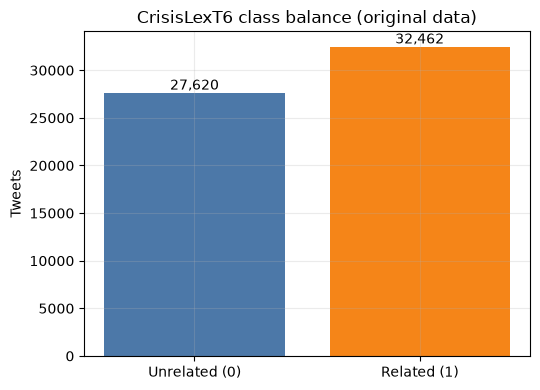

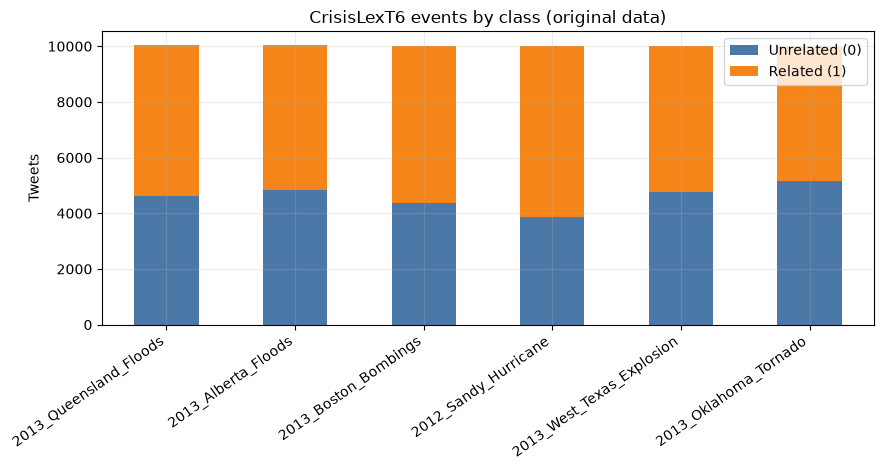

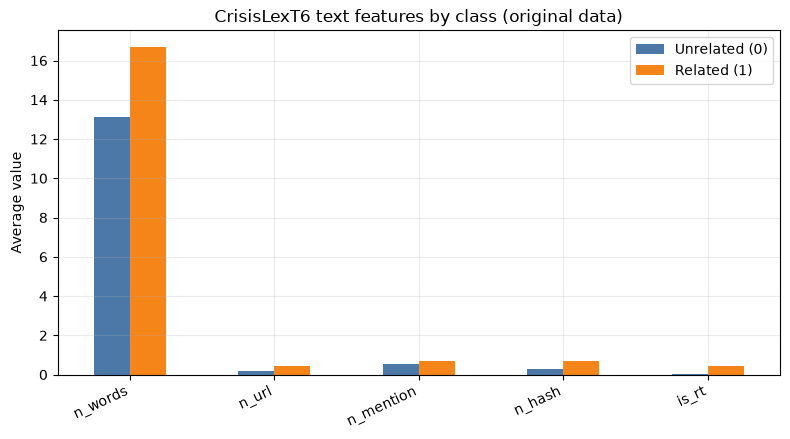

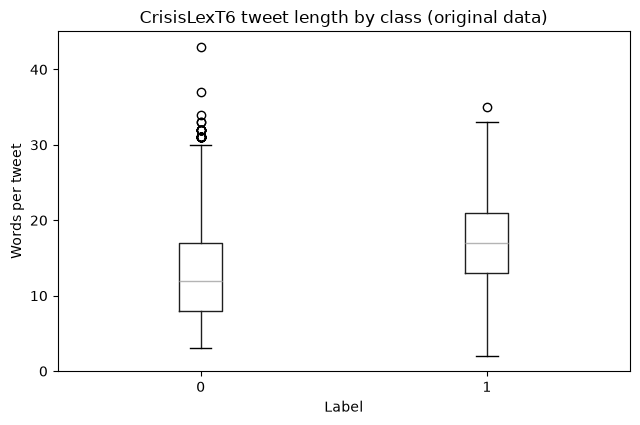

In [10]:
plot_class_balance(crisis_t6, "CrisisLexT6 class balance (original data)")
plot_event_distribution(crisis_t6, "CrisisLexT6 events by class (original data)")
plot_text_feature_summary(featured_datasets["CrisisLexT6"], "CrisisLexT6 text features by class (original data)")
plot_tweet_length_boxplot(featured_datasets["CrisisLexT6"], "CrisisLexT6 tweet length by class (original data)")


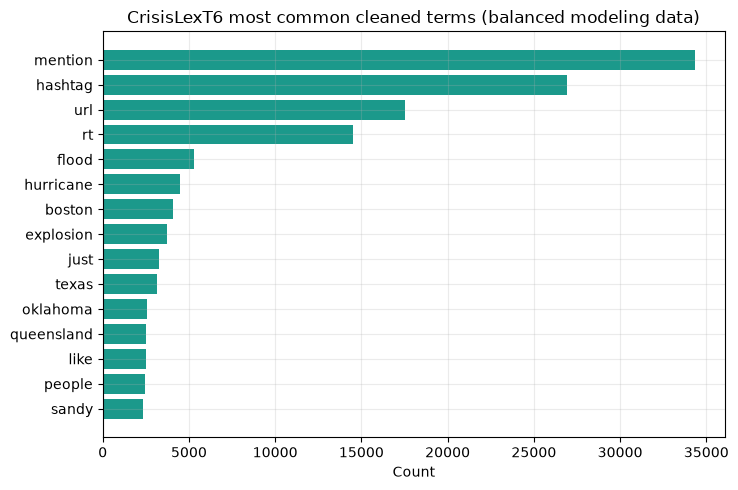

,term,count
5657,mention,34338
4191,hashtag,26922
9400,url,17524
7611,rt,14497
3673,flood,5269
4476,hurricane,4488
1398,boston,4074
3404,explosion,3704
4883,just,3242
8836,texas,3133


In [11]:
plot_top_terms(splits["CrisisLexT6"]["balanced"], "CrisisLexT6 most common cleaned terms (balanced modeling data)")


## **4. CrisisLexT6 modeling**


CrisisLexT6: loaded saved full RoBERTa result from outputs/notebook_roberta_runs/crisislext6/results.json.


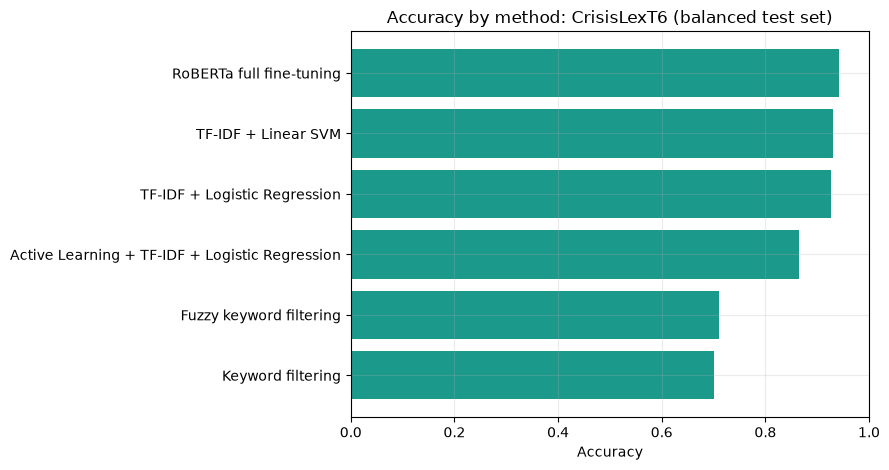

,dataset,method,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,support_0,support_1,notes
0,CrisisLexT6,RoBERTa full fine-tuning,0.942614,0.957009,0.926865,0.941696,0.929098,0.958364,0.943504,5524,5524,Loaded saved full RoBERTa result; train rows =...
1,CrisisLexT6,TF-IDF + Linear SVM,0.930123,0.928262,0.932295,0.930275,0.932000,0.927951,0.929971,5524,5524,
2,CrisisLexT6,TF-IDF + Logistic Regression,0.926231,0.917391,0.936821,0.927004,0.935454,0.915641,0.925441,5524,5524,
3,CrisisLexT6,Active Learning + TF-IDF + Logistic Regression,0.864229,0.929181,0.788559,0.853114,0.816352,0.939899,0.873780,5524,5524,final labeled samples = 360
4,CrisisLexT6,Fuzzy keyword filtering,0.711441,0.640317,0.964881,0.769786,0.928781,0.458001,0.613482,5524,5524,
5,CrisisLexT6,Keyword filtering,0.701303,0.629122,0.980811,0.766553,0.956486,0.421796,0.585427,5524,5524,


In [12]:
run_classical_methods("CrisisLexT6")
add_roberta_result("CrisisLexT6")
plot_dataset_results("CrisisLexT6")


## **5. CrisisLexT6 explainability**


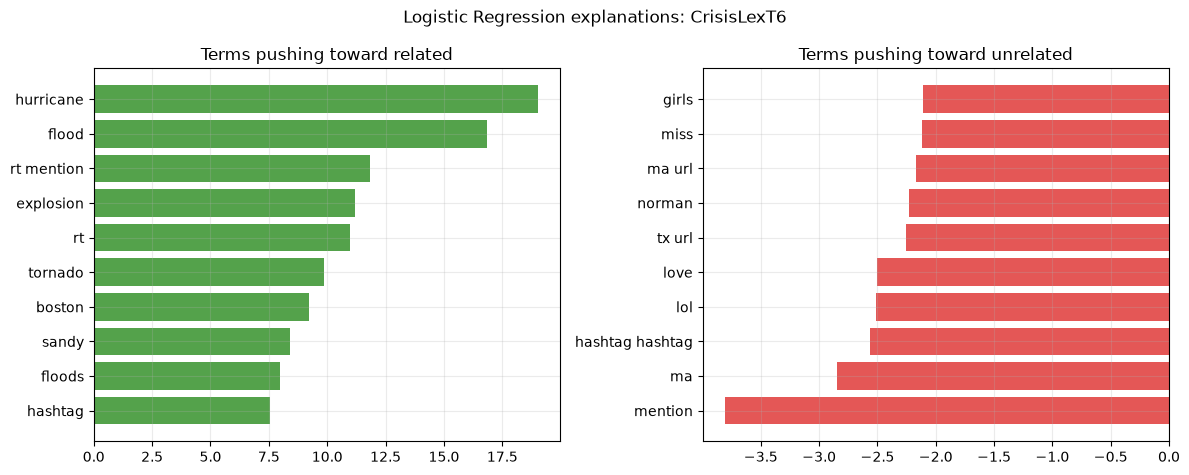

,term,coefficient,direction
0,hurricane,19.018936,related
1,flood,16.828016,related
2,rt mention,11.848494,related
3,explosion,11.185282,related
4,rt,10.968031,related
5,tornado,9.871874,related
6,boston,9.213308,related
7,sandy,8.387694,related
8,floods,7.967880,related
9,hashtag,7.535160,related


In [13]:
plot_logreg_terms("CrisisLexT6", top_n=10)


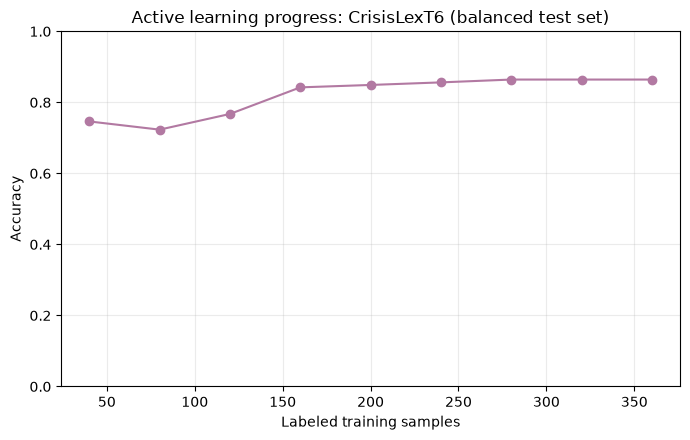

,round,labeled_samples,accuracy
0,0,40,0.746289
1,1,80,0.723208
2,2,120,0.767379
3,3,160,0.842234
4,4,200,0.849022
5,5,240,0.856264
6,6,280,0.864229
7,7,320,0.864229
8,8,360,0.864229


In [14]:
plot_active_learning_history("CrisisLexT6")


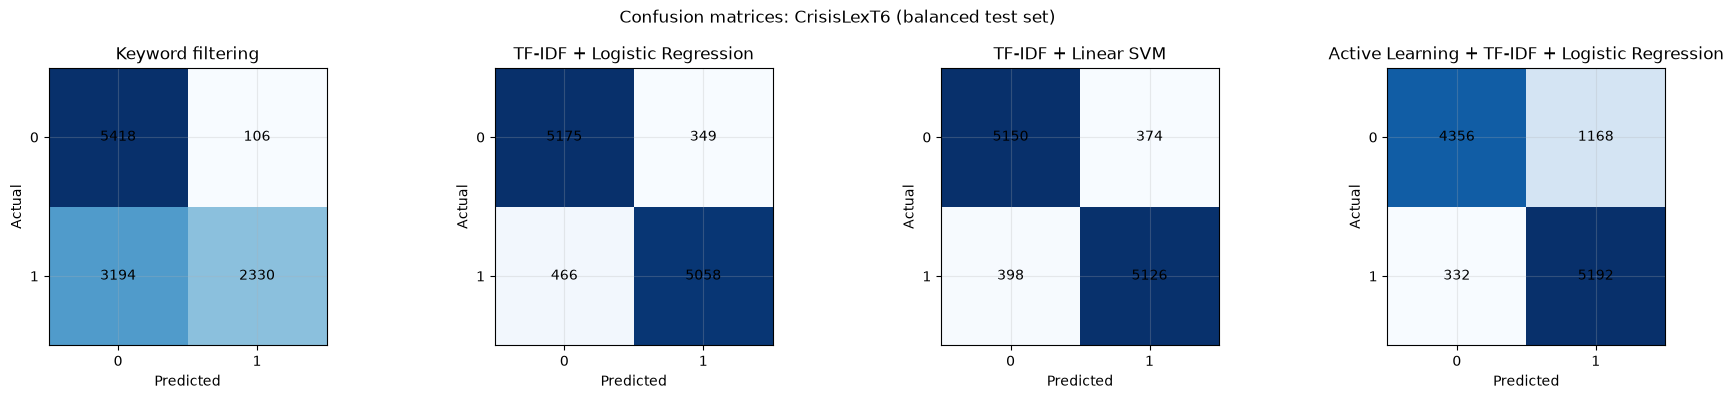

In [15]:
plot_confusion_matrices(
    "CrisisLexT6",
    [
        "Keyword filtering",
        "TF-IDF + Logistic Regression",
        "TF-IDF + Linear SVM",
        "Active Learning + TF-IDF + Logistic Regression",
    ],
)


**CrisisLexT6 takeaway.** This dataset is relatively balanced compared with CrisisLexT26, and the classical TF-IDF models usually perform strongly because the train and test data come from the same public CrisisLex distribution.


# **Part 2. CrisisLexT26**

CrisisLexT26 has more events and uses an informativeness label. We map it into the same binary task: unrelated vs. related.


## **6. CrisisLexT26 EDA**

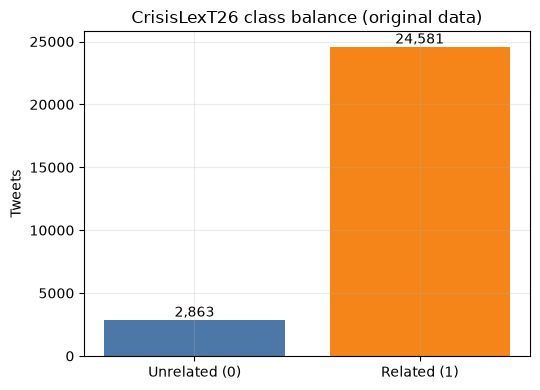

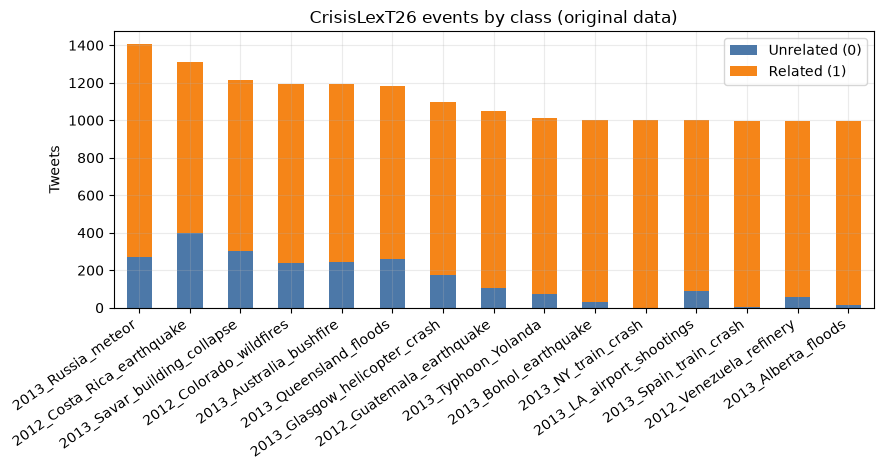

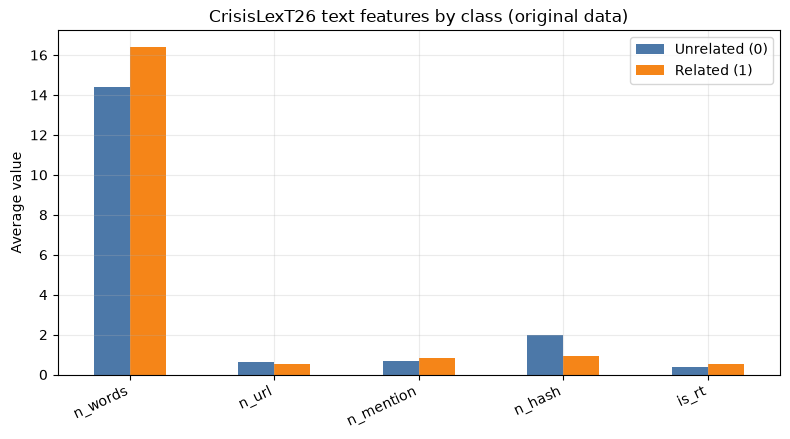

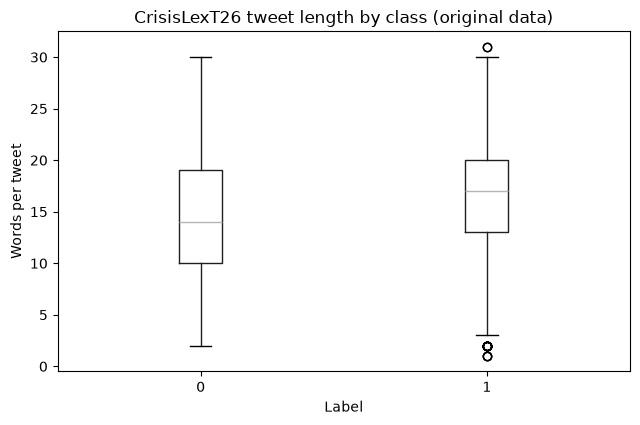

In [16]:
plot_class_balance(crisis_t26, "CrisisLexT26 class balance (original data)")
plot_event_distribution(crisis_t26, "CrisisLexT26 events by class (original data)", top_n=15)
plot_text_feature_summary(featured_datasets["CrisisLexT26"], "CrisisLexT26 text features by class (original data)")
plot_tweet_length_boxplot(featured_datasets["CrisisLexT26"], "CrisisLexT26 tweet length by class (original data)")


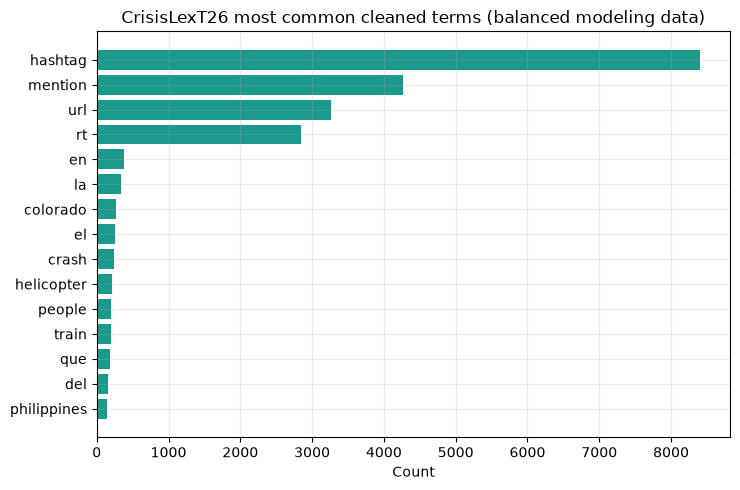

,term,count
2009,hashtag,8401
2675,mention,4260
4382,url,3258
3623,rt,2851
1505,en,381
2389,la,341
1010,colorado,270
1479,el,250
1135,crash,245
2049,helicopter,218


In [17]:
plot_top_terms(splits["CrisisLexT26"]["balanced"], "CrisisLexT26 most common cleaned terms (balanced modeling data)")


## **7. CrisisLexT26 modeling**


CrisisLexT26: loaded saved full RoBERTa result from outputs/notebook_roberta_runs/crisislext26/results.json.


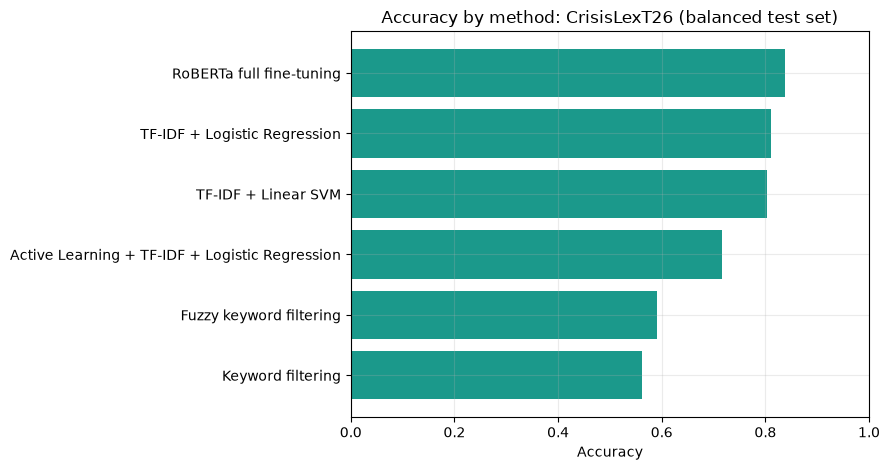

,dataset,method,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,support_0,support_1,notes
0,CrisisLexT26,RoBERTa full fine-tuning,0.838569,0.846429,0.827225,0.836717,0.831058,0.849913,0.840380,573,573,Loaded saved full RoBERTa result; train rows =...
1,CrisisLexT26,TF-IDF + Logistic Regression,0.811518,0.801012,0.828970,0.814751,0.822785,0.794066,0.808171,573,573,
2,CrisisLexT26,TF-IDF + Linear SVM,0.802792,0.789649,0.825480,0.807167,0.817185,0.780105,0.798214,573,573,
3,CrisisLexT26,Active Learning + TF-IDF + Logistic Regression,0.715532,0.679767,0.815009,0.741270,0.769063,0.616056,0.684109,573,573,final labeled samples = 360
4,CrisisLexT26,Fuzzy keyword filtering,0.590750,0.553061,0.945899,0.698004,0.813253,0.235602,0.365359,573,573,
5,CrisisLexT26,Keyword filtering,0.561082,0.533654,0.968586,0.688159,0.830189,0.153578,0.259205,573,573,


In [18]:
run_classical_methods("CrisisLexT26")
add_roberta_result("CrisisLexT26")
plot_dataset_results("CrisisLexT26")


## **8. CrisisLexT26 explainability**


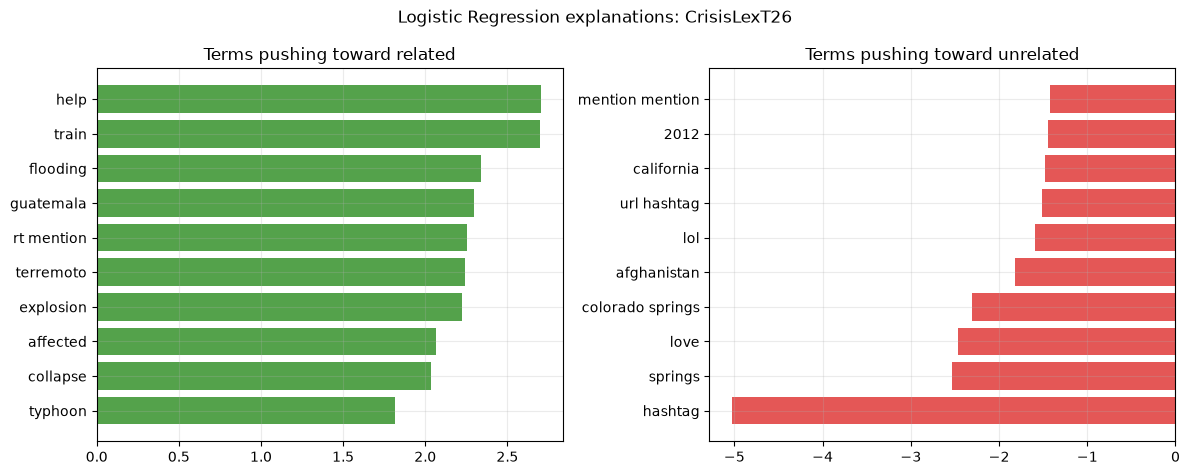

,term,coefficient,direction
0,help,2.702082,related
1,train,2.697861,related
2,flooding,2.341686,related
3,guatemala,2.296835,related
4,rt mention,2.251561,related
5,terremoto,2.244954,related
6,explosion,2.224999,related
7,affected,2.064619,related
8,collapse,2.034634,related
9,typhoon,1.816304,related


In [19]:
plot_logreg_terms("CrisisLexT26", top_n=10)


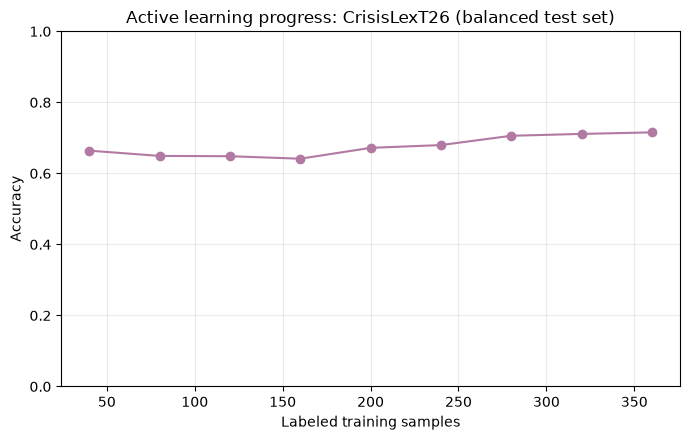

,round,labeled_samples,accuracy
0,0,40,0.664049
1,1,80,0.649215
2,2,120,0.648342
3,3,160,0.641361
4,4,200,0.671902
5,5,240,0.679756
6,6,280,0.705934
7,7,320,0.711169
8,8,360,0.715532


In [20]:
plot_active_learning_history("CrisisLexT26")


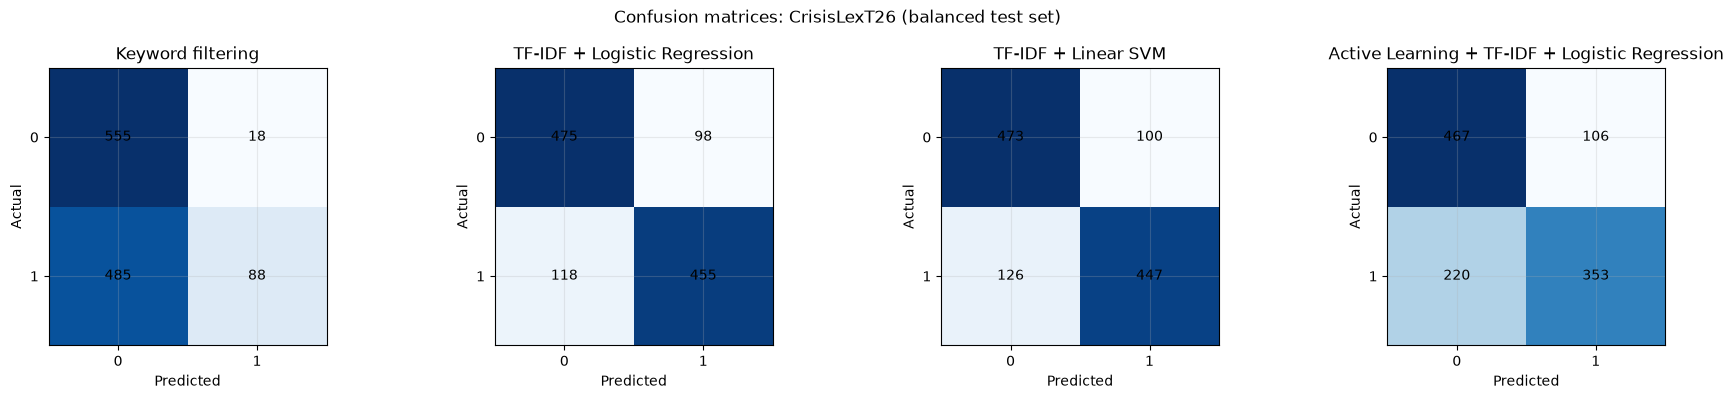

In [21]:
plot_confusion_matrices(
    "CrisisLexT26",
    [
        "Keyword filtering",
        "TF-IDF + Logistic Regression",
        "TF-IDF + Linear SVM",
        "Active Learning + TF-IDF + Logistic Regression",
    ],
)


**CrisisLexT26 takeaway.** CrisisLexT26 is much more imbalanced before balancing and covers more events. This usually makes it a harder and more realistic dataset than CrisisLexT6.


# **Part 3. Kaggle Disaster Tweets**

Kaggle Disaster Tweets is not a replacement for the paper's Germany flood or Chile wildfire datasets. In this revised structure, it is treated as its own third dataset and modeled separately.


## **9. Kaggle EDA**


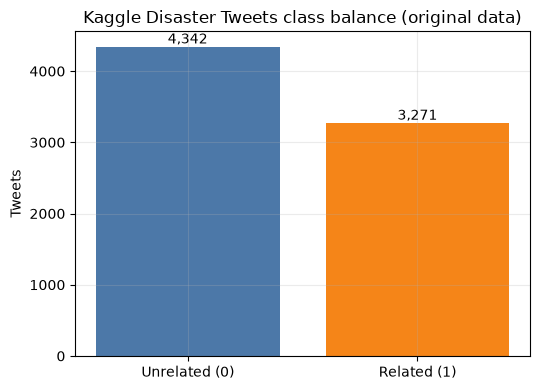

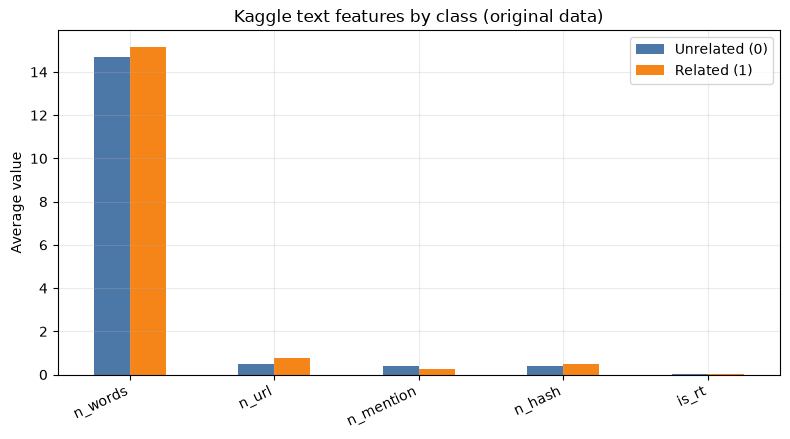

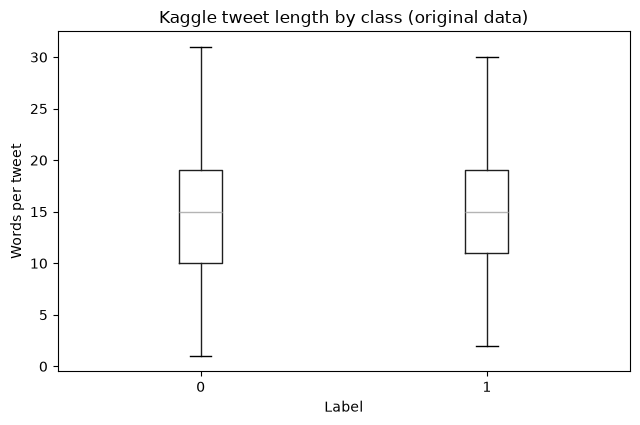

In [22]:
plot_class_balance(kaggle, "Kaggle Disaster Tweets class balance (original data)")
plot_text_feature_summary(featured_datasets["Kaggle Disaster Tweets"], "Kaggle text features by class (original data)")
plot_tweet_length_boxplot(featured_datasets["Kaggle Disaster Tweets"], "Kaggle tweet length by class (original data)")


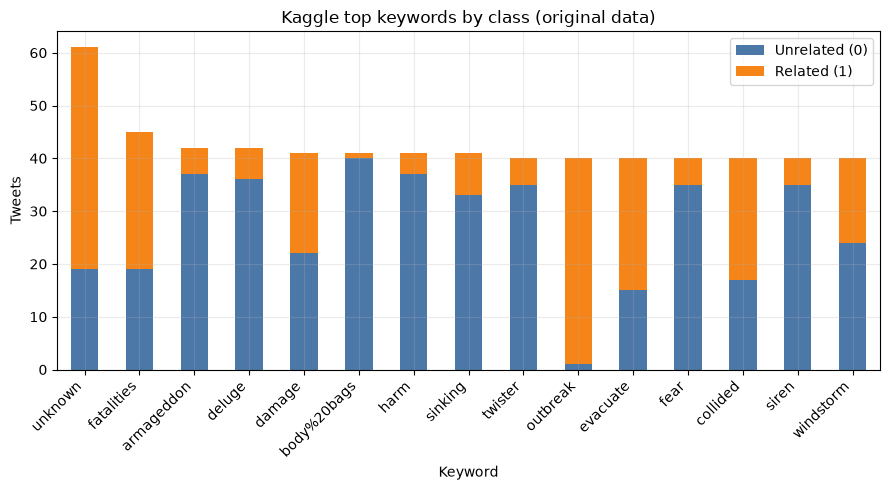

label,0,1,total
keyword,,,
unknown,19,42,61
fatalities,19,26,45
armageddon,37,5,42
deluge,36,6,42
damage,22,19,41
body%20bags,40,1,41
harm,37,4,41
sinking,33,8,41
twister,35,5,40


In [23]:
kaggle_keyword_counts = (
    kaggle.groupby(["keyword", "label"])
    .size()
    .unstack(fill_value=0)
)
kaggle_keyword_counts["total"] = kaggle_keyword_counts.sum(axis=1)
kaggle_keyword_counts = kaggle_keyword_counts.sort_values("total", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
kaggle_keyword_counts[[0, 1]].plot(kind="bar", stacked=True, ax=ax, color=[PALETTE["unrelated"], PALETTE["related"]])
ax.set_title("Kaggle top keywords by class (original data)")
ax.set_xlabel("Keyword")
ax.set_ylabel("Tweets")
ax.legend(["Unrelated (0)", "Related (1)"])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

kaggle_keyword_counts.head(10)


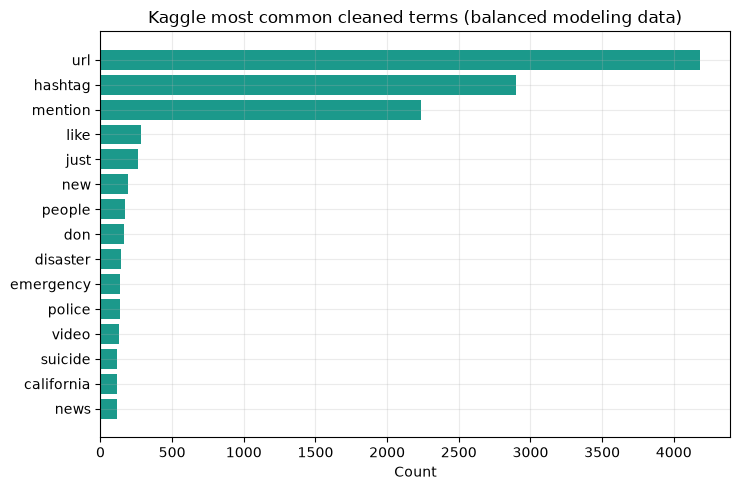

,term,count
4891,url,4183
2187,hashtag,2898
2964,mention,2235
2745,like,284
2564,just,260
3184,new,192
3435,people,172
1467,don,162
1425,disaster,143
1610,emergency,134


In [24]:
plot_top_terms(splits["Kaggle Disaster Tweets"]["balanced"], "Kaggle most common cleaned terms (balanced modeling data)")


## **10. Kaggle modeling**


Kaggle Disaster Tweets: loaded saved full RoBERTa result from outputs/notebook_roberta_runs/kaggle_disaster_tweets/results.json.


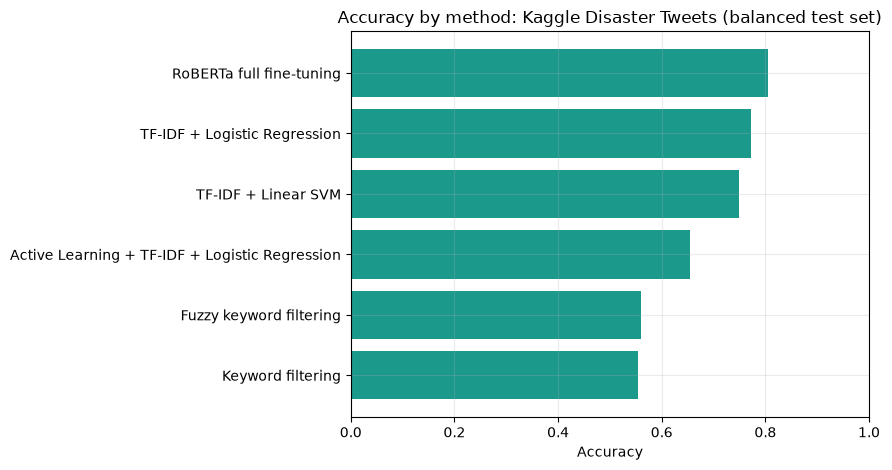

,dataset,method,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,support_0,support_1,notes
0,Kaggle Disaster Tweets,RoBERTa full fine-tuning,0.805195,0.791545,0.829008,0.809843,0.820225,0.781346,0.800313,655,654,Loaded saved full RoBERTa result; train rows =...
1,Kaggle Disaster Tweets,TF-IDF + Logistic Regression,0.773109,0.752825,0.813740,0.782098,0.797005,0.732416,0.763347,655,654,
2,Kaggle Disaster Tweets,TF-IDF + Linear SVM,0.749427,0.735252,0.780153,0.757037,0.765472,0.718654,0.741325,655,654,
3,Kaggle Disaster Tweets,Active Learning + TF-IDF + Logistic Regression,0.654698,0.664506,0.625954,0.644654,0.645954,0.683486,0.664190,655,654,final labeled samples = 360
4,Kaggle Disaster Tweets,Fuzzy keyword filtering,0.559969,0.537089,0.873282,0.665116,0.659836,0.246177,0.358575,655,654,
5,Kaggle Disaster Tweets,Keyword filtering,0.554622,0.531972,0.914504,0.672656,0.693989,0.194190,0.303465,655,654,


In [25]:
run_classical_methods("Kaggle Disaster Tweets")
add_roberta_result("Kaggle Disaster Tweets")
plot_dataset_results("Kaggle Disaster Tweets")


## **11. Kaggle explainability**


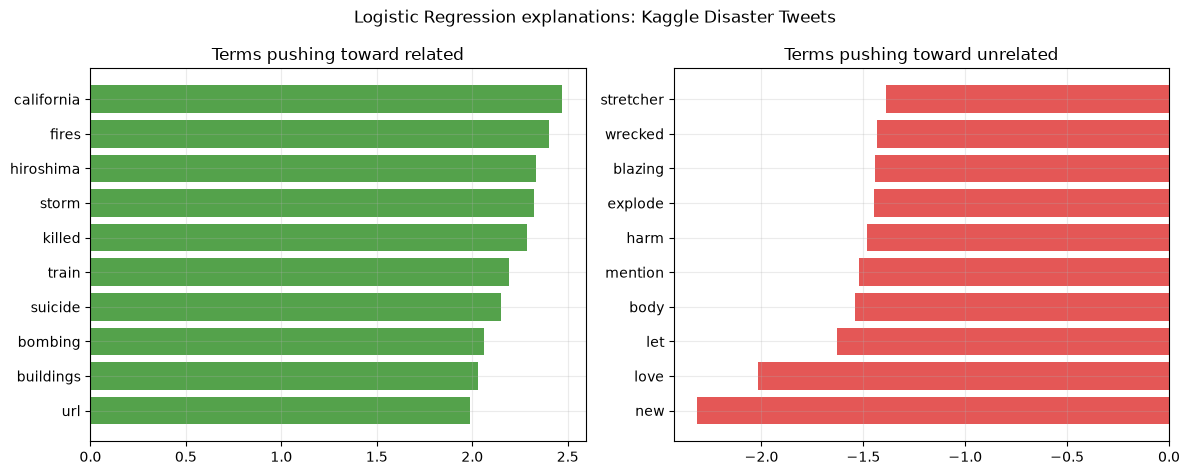

,term,coefficient,direction
0,california,2.469678,related
1,fires,2.399612,related
2,hiroshima,2.331577,related
3,storm,2.324277,related
4,killed,2.286268,related
5,train,2.189891,related
6,suicide,2.151779,related
7,bombing,2.061773,related
8,buildings,2.028189,related
9,url,1.986250,related


In [26]:
plot_logreg_terms("Kaggle Disaster Tweets", top_n=10)


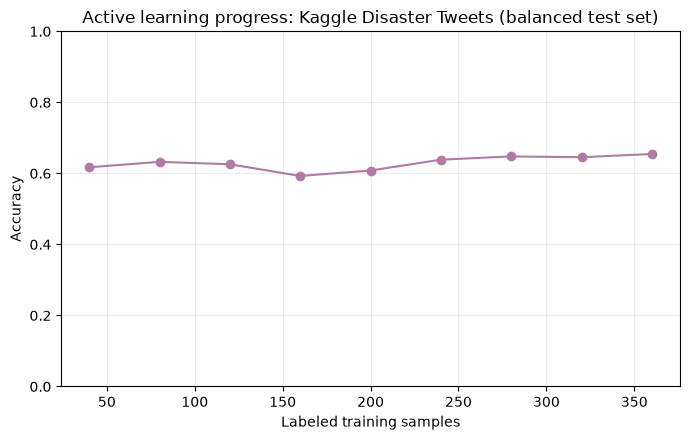

,round,labeled_samples,accuracy
0,0,40,0.617265
1,1,80,0.632544
2,2,120,0.625668
3,3,160,0.592819
4,4,200,0.608098
5,5,240,0.638655
6,6,280,0.647823
7,7,320,0.645531
8,8,360,0.654698


In [27]:
plot_active_learning_history("Kaggle Disaster Tweets")


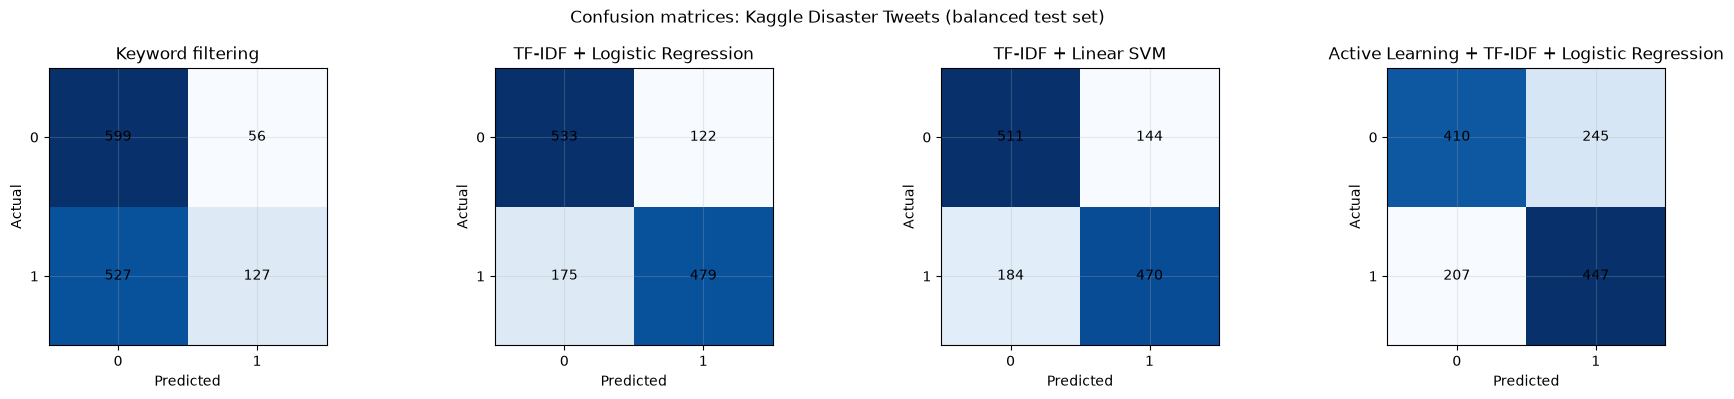

In [28]:
plot_confusion_matrices(
    "Kaggle Disaster Tweets",
    [
        "Keyword filtering",
        "TF-IDF + Logistic Regression",
        "TF-IDF + Linear SVM",
        "Active Learning + TF-IDF + Logistic Regression",
    ],
)


**Kaggle takeaway.** Kaggle is a different disaster-tweet dataset with its own keyword metadata and label conventions. Its results should be interpreted as a separate dataset comparison, not as an exact substitute for the private event datasets in the paper.


# **Part 4. Combined comparison**

The combined view compares the same six approaches across all three datasets.


In [29]:
final_results = results_table()
final_results


,dataset,method,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,support_0,support_1,notes
0,CrisisLexT26,RoBERTa full fine-tuning,0.838569,0.846429,0.827225,0.836717,0.831058,0.849913,0.840380,573,573,Loaded saved full RoBERTa result; train rows =...
1,CrisisLexT26,TF-IDF + Logistic Regression,0.811518,0.801012,0.828970,0.814751,0.822785,0.794066,0.808171,573,573,
2,CrisisLexT26,TF-IDF + Linear SVM,0.802792,0.789649,0.825480,0.807167,0.817185,0.780105,0.798214,573,573,
3,CrisisLexT26,Active Learning + TF-IDF + Logistic Regression,0.715532,0.679767,0.815009,0.741270,0.769063,0.616056,0.684109,573,573,final labeled samples = 360
4,CrisisLexT26,Fuzzy keyword filtering,0.590750,0.553061,0.945899,0.698004,0.813253,0.235602,0.365359,573,573,
5,CrisisLexT26,Keyword filtering,0.561082,0.533654,0.968586,0.688159,0.830189,0.153578,0.259205,573,573,
6,CrisisLexT6,RoBERTa full fine-tuning,0.942614,0.957009,0.926865,0.941696,0.929098,0.958364,0.943504,5524,5524,Loaded saved full RoBERTa result; train rows =...
7,CrisisLexT6,TF-IDF + Linear SVM,0.930123,0.928262,0.932295,0.930275,0.932000,0.927951,0.929971,5524,5524,
8,CrisisLexT6,TF-IDF + Logistic Regression,0.926231,0.917391,0.936821,0.927004,0.935454,0.915641,0.925441,5524,5524,
9,CrisisLexT6,Active Learning + TF-IDF + Logistic Regression,0.864229,0.929181,0.788559,0.853114,0.816352,0.939899,0.873780,5524,5524,final labeled samples = 360


In [30]:
accuracy_matrix = final_results.pivot_table(
    index="method",
    columns="dataset",
    values="accuracy",
    aggfunc="first",
)

accuracy_matrix


dataset,CrisisLexT26,CrisisLexT6,Kaggle Disaster Tweets
method,,,
Active Learning + TF-IDF + Logistic Regression,0.715532,0.864229,0.654698
Fuzzy keyword filtering,0.590750,0.711441,0.559969
Keyword filtering,0.561082,0.701303,0.554622
RoBERTa full fine-tuning,0.838569,0.942614,0.805195
TF-IDF + Linear SVM,0.802792,0.930123,0.749427
TF-IDF + Logistic Regression,0.811518,0.926231,0.773109


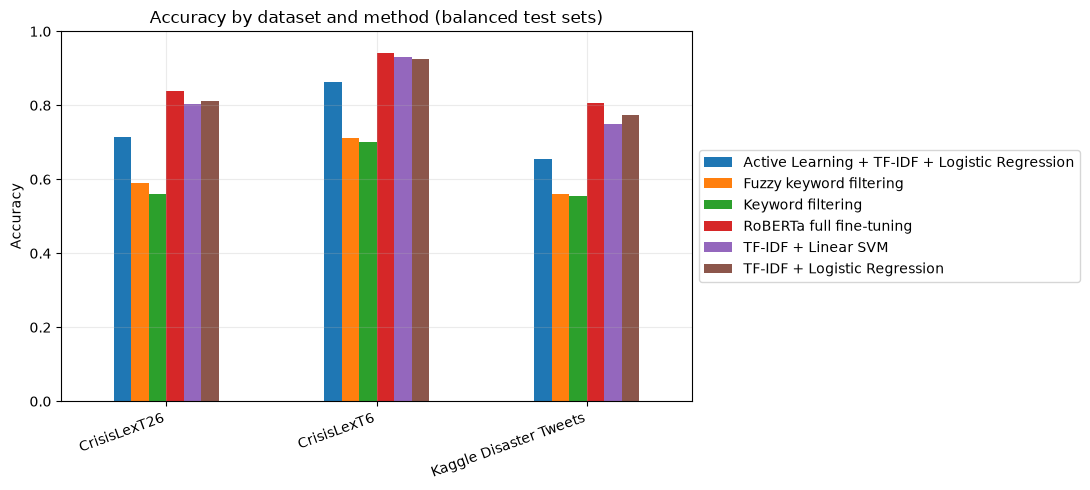

In [31]:
fig, ax = plt.subplots(figsize=(11, 5))
accuracy_matrix.T.plot(kind="bar", ax=ax)
ax.set_title("Accuracy by dataset and method (balanced test sets)")
ax.set_xlabel("")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


In [32]:
best_overall = (
    final_results.sort_values(["dataset", "accuracy"], ascending=[True, False])
    .groupby("dataset")
    .head(1)
    .reset_index(drop=True)
)

course_friendly_results = final_results[
    ~final_results["method"].str.contains("RoBERTa", na=False)
].copy()
best_course_friendly = (
    course_friendly_results.sort_values(["dataset", "accuracy"], ascending=[True, False])
    .groupby("dataset")
    .head(1)
    .reset_index(drop=True)
)

print("Best overall method by dataset:")
display(best_overall)

print("Best course-friendly non-transformer method by dataset:")
display(best_course_friendly)


Best overall method by dataset:


,dataset,method,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,support_0,support_1,notes
0,CrisisLexT26,RoBERTa full fine-tuning,0.838569,0.846429,0.827225,0.836717,0.831058,0.849913,0.840380,573,573,Loaded saved full RoBERTa result; train rows =...
1,CrisisLexT6,RoBERTa full fine-tuning,0.942614,0.957009,0.926865,0.941696,0.929098,0.958364,0.943504,5524,5524,Loaded saved full RoBERTa result; train rows =...
2,Kaggle Disaster Tweets,RoBERTa full fine-tuning,0.805195,0.791545,0.829008,0.809843,0.820225,0.781346,0.800313,655,654,Loaded saved full RoBERTa result; train rows =...


Best course-friendly non-transformer method by dataset:


,dataset,method,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,support_0,support_1,notes
0,CrisisLexT26,TF-IDF + Logistic Regression,0.811518,0.801012,0.828970,0.814751,0.822785,0.794066,0.808171,573,573,
1,CrisisLexT6,TF-IDF + Linear SVM,0.930123,0.928262,0.932295,0.930275,0.932000,0.927951,0.929971,5524,5524,
2,Kaggle Disaster Tweets,TF-IDF + Logistic Regression,0.773109,0.752825,0.813740,0.782098,0.797005,0.732416,0.763347,655,654,


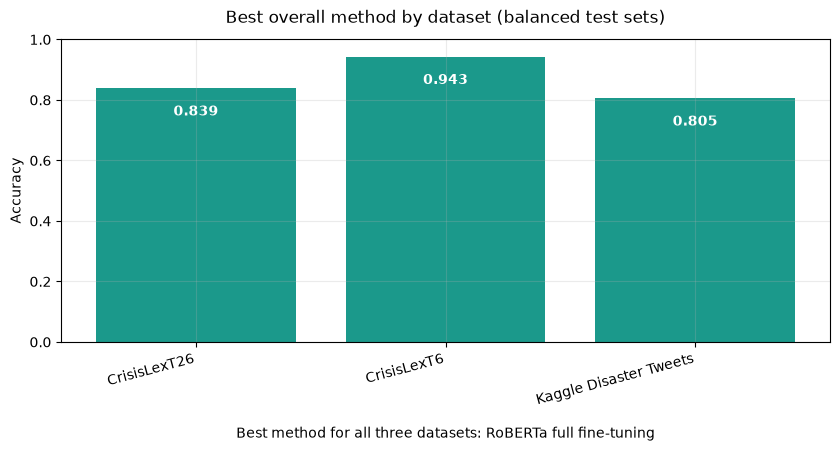

In [33]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(best_overall["dataset"], best_overall["accuracy"], color=PALETTE["teal"])
ax.set_title("Best overall method by dataset (balanced test sets)", pad=12)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_xlabel("")
plt.xticks(rotation=15, ha="right")

for bar, (_, row) in zip(bars, best_overall.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        row["accuracy"] - 0.055,
        f"{row['accuracy']:.3f}",
        ha="center",
        va="top",
        color="white",
        fontsize=10,
        fontweight="bold",
    )

ax.text(
    0.5,
    -0.28,
    "Best method for all three datasets: RoBERTa full fine-tuning",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=10,
)
plt.tight_layout()
plt.show()


## **12. Combined interpretation**


The key improvement in this version is that datasets are no longer mixed together before interpretation. Each dataset gets the same modeling treatment, then the results are compared afterward.

Interpretation rules:

- Compare methods within the same dataset first.
- Compare datasets only after noting that label definitions, event coverage, and source distributions differ.
- RoBERTa full fine-tuning is now included because the completed full-run outputs were saved and loaded from `outputs/notebook_roberta_runs`.
- Use the TF-IDF and active-learning rows as the main course-friendly comparison, and use the RoBERTa rows as the transformer-based fine-tuning comparison.

## **13. Paper vs Our Results**


**What the paper did**

The paper studied disaster-related tweet classification with methods ranging from keyword filtering to RoBERTa fine-tuning and active learning. Its main public comparison point for us is the CrisisLex-based result, because the Germany flood and Chile wildfire datasets are not fully available in our project files.

The paper reported strong performance for transformer fine-tuning on CrisisLex. It also evaluated active learning and the combination of generic fine-tuning plus active learning.

**What we did**

We reorganized the project into three separate datasets:

- CrisisLexT6
- CrisisLexT26
- Kaggle Disaster Tweets

For each dataset, we ran the same six approaches. Keyword, fuzzy keyword, TF-IDF, active learning, and RoBERTa are now all represented in the results. RoBERTa was trained separately on each balanced dataset split and saved under `outputs/notebook_roberta_runs`.

**What we achieved**

The full RoBERTa run is the strongest overall method on all three datasets. The TF-IDF models remain the strongest course-friendly non-transformer baselines and provide an important comparison point for the simpler methods.

In [34]:
def closest_roberta_method():
    if not final_results.empty and (final_results["method"] == ROBERTA_FULL_METHOD_NAME).any():
        return ROBERTA_FULL_METHOD_NAME
    return ROBERTA_SMOKE_METHOD_NAME


paper_reference = pd.DataFrame([
    {
        "method_group": "Keyword filtering",
        "paper_crisislex_accuracy": 0.700,
        "our_closest_method": "Keyword filtering",
        "comparison_note": "Closest rule-based comparison. Our value depends on separate T6/T26/Kaggle splits.",
    },
    {
        "method_group": "Fuzzy keyword filtering",
        "paper_crisislex_accuracy": 0.720,
        "our_closest_method": "Fuzzy keyword filtering",
        "comparison_note": "Comparable idea, but keyword list and fuzzy matching implementation may differ.",
    },
    {
        "method_group": "Generic fine-tuning / RoBERTa",
        "paper_crisislex_accuracy": 0.940,
        "our_closest_method": closest_roberta_method(),
        "comparison_note": "Completed full RoBERTa run. Comparable at the transformer fine-tuning level, but exact values may differ due to checkpoint, split, preprocessing, hyperparameters, and randomness.",
    },
    {
        "method_group": "Active learning",
        "paper_crisislex_accuracy": 0.590,
        "our_closest_method": "Active Learning + TF-IDF + Logistic Regression",
        "comparison_note": "Conceptually related, but our query strategy and model differ from the paper.",
    },
    {
        "method_group": "Generic fine-tuning + Active learning",
        "paper_crisislex_accuracy": 0.940,
        "our_closest_method": "Not run",
        "comparison_note": "Paper reported this method, but we did not execute it because it would require repeated RoBERTa fine-tuning inside active-learning rounds.",
    },
])


def best_accuracy_for_method(method_name):
    rows = final_results[final_results["method"] == method_name]
    if rows.empty:
        return np.nan
    return rows["accuracy"].max()


def dataset_accuracy_for_method(dataset_name, method_name):
    rows = final_results[
        (final_results["dataset"] == dataset_name)
        & (final_results["method"] == method_name)
    ]
    if rows.empty:
        return np.nan
    return rows["accuracy"].iloc[0]


paper_vs_ours = paper_reference.copy()
for dataset_name in ["CrisisLexT6", "CrisisLexT26", "Kaggle Disaster Tweets"]:
    paper_vs_ours[dataset_name] = paper_vs_ours["our_closest_method"].map(
        lambda method: dataset_accuracy_for_method(dataset_name, method)
        if method != "Not run"
        else np.nan
    )

paper_vs_ours["best_our_accuracy"] = paper_vs_ours[
    ["CrisisLexT6", "CrisisLexT26", "Kaggle Disaster Tweets"]
].max(axis=1)

paper_vs_ours


,method_group,paper_crisislex_accuracy,our_closest_method,comparison_note,CrisisLexT6,CrisisLexT26,Kaggle Disaster Tweets,best_our_accuracy
0,Keyword filtering,0.70,Keyword filtering,Closest rule-based comparison. Our value depen...,0.701303,0.561082,0.554622,0.701303
1,Fuzzy keyword filtering,0.72,Fuzzy keyword filtering,"Comparable idea, but keyword list and fuzzy ma...",0.711441,0.590750,0.559969,0.711441
2,Generic fine-tuning / RoBERTa,0.94,RoBERTa full fine-tuning,Completed full RoBERTa run. Comparable at the ...,0.942614,0.838569,0.805195,0.942614
3,Active learning,0.59,Active Learning + TF-IDF + Logistic Regression,"Conceptually related, but our query strategy a...",0.864229,0.715532,0.654698,0.864229
4,Generic fine-tuning + Active learning,0.94,Not run,"Paper reported this method, but we did not exe...",NaN,NaN,NaN,NaN


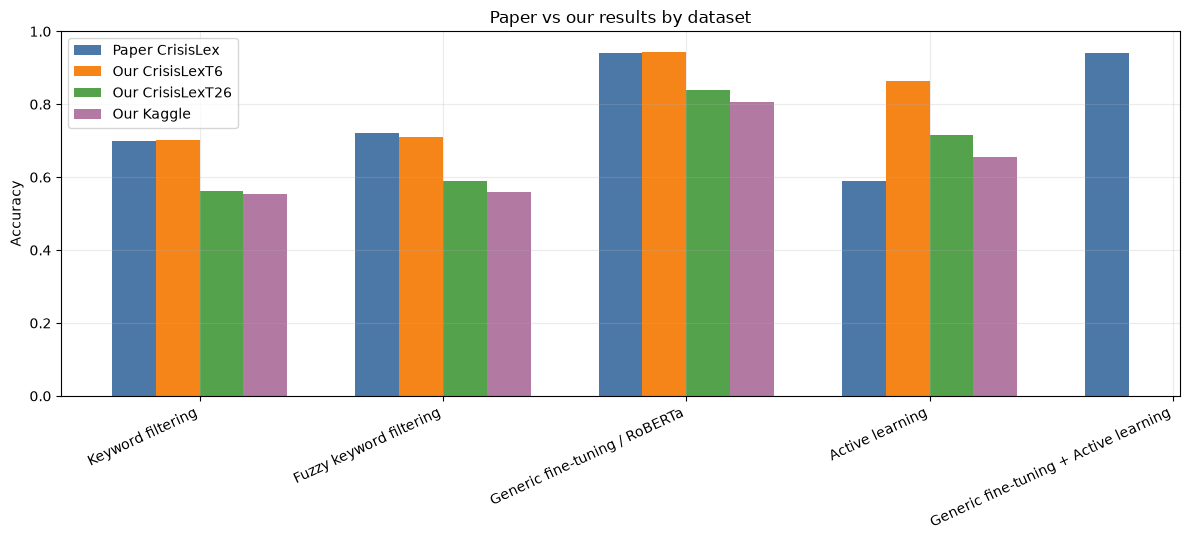

In [35]:
plot_data = paper_vs_ours.dropna(subset=["paper_crisislex_accuracy"]).copy()
series = [
    ("Paper CrisisLex", "paper_crisislex_accuracy", PALETTE["unrelated"]),
    ("Our CrisisLexT6", "CrisisLexT6", PALETTE["related"]),
    ("Our CrisisLexT26", "CrisisLexT26", PALETTE["green"]),
    ("Our Kaggle", "Kaggle Disaster Tweets", PALETTE["purple"]),
]

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(plot_data))
width = 0.18

for offset, (label, column, color) in zip([-1.5, -0.5, 0.5, 1.5], series):
    ax.bar(
        x + offset * width,
        plot_data[column],
        width,
        label=label,
        color=color,
    )

ax.set_title("Paper vs our results by dataset")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(plot_data["method_group"], rotation=25, ha="right")
ax.legend()
plt.tight_layout()
plt.show()


**How to read this comparison**

This table and chart are useful for orientation, but they are not exact reproduction claims.

- The paper's CrisisLex setup is not identical to our separate CrisisLexT6 and CrisisLexT26 setup.
- Kaggle is included as a third dataset, not as a replacement for the paper's private event datasets.
- Our active-learning method is course-friendly uncertainty sampling with TF-IDF + Logistic Regression, not the paper's exact active-learning implementation.
- RoBERTa now uses completed full-run outputs, but exact reproduction is still limited by checkpoint, split, preprocessing, hyperparameter, and randomness differences.
- `Generic fine-tuning + Active learning` is included as a paper-reported method. We show the paper's CrisisLex accuracy, but our dataset columns stay empty because we did not run repeated RoBERTa active-learning rounds.

The main takeaway is that our project reproduces the paper's general modeling direction, extends it with course-friendly baselines, and documents why exact numerical reproduction is difficult.


## **14. Completed RoBERTa runtime**


The full RoBERTa run has now been completed for all three balanced datasets. The results were saved under `outputs/notebook_roberta_runs`, and the notebook is set to load those saved results instead of retraining by default.

Completed CPU runtime:

- CrisisLexT6: **44,192 training tweets**, **11,048 test tweets**, about **4.94 hours training** and **5.21 hours total**
- CrisisLexT26: **4,580 training tweets**, **1,146 test tweets**, about **0.50 hours training** and **0.53 hours total**
- Kaggle: **5,233 training tweets**, **1,309 test tweets**, about **0.60 hours training** and **0.63 hours total**

Total completed runtime: about **6.03 hours training** and **6.37 hours total**.

This is lower than the earlier 7.5 to 8.5 hour estimate, which was only a rough scaling estimate based on the previous 40k CrisisLex subset run.

# **Part 5. Sources of irreproducibility**


Exact reproduction of the paper is difficult for several reasons:

1. **Unavailable event-specific datasets:** the Germany flood and Chile wildfire Twitter/X datasets from the paper are not fully available here.
2. **Dataset restructuring:** this notebook uses CrisisLexT6, CrisisLexT26, and Kaggle as three separate datasets rather than the paper's exact event setup.
3. **Label mapping:** CrisisLexT26 informativeness labels are mapped into a binary related/unrelated task.
4. **Balancing:** each dataset is balanced by downsampling the larger class, which can change the data distribution.
5. **Train/test split:** the random split may differ from the paper.
6. **Preprocessing:** URL, mention, hashtag, and punctuation handling may differ.
7. **Active learning strategy:** this notebook uses uncertainty sampling with TF-IDF + Logistic Regression, not the paper's exact active-learning setup.
8. **RoBERTa setup:** the model family follows the paper's transformer-based fine-tuning approach, but max length, epoch setup, checkpoint loading, and randomness may differ.
9. **Randomness:** sampling, splitting, and model initialization can change results.
10. **Domain shift:** Kaggle has different collection rules and labels, so it should not be treated as an exact replacement for the paper's private event datasets.

Final framing:

This notebook provides a coherent course-project comparison across three disaster-tweet datasets and six methods. It keeps the paper's ideas in view, but it is best described as a structured reproduction-and-extension rather than an exact reproduction.